In [1]:
import pyodbc
import pandas as pd

mdb_path = r"C:\Users\schulz0022\Documents\river-pollution-brazil\data\sensor_data\raw\47000_conventional_pluviometrica_mdb_20260328T124329Z_0a88a978\47000.mdb"

conn = pyodbc.connect( 
    rf"Driver={{Microsoft Access Driver (*.mdb, *.accdb)}};DBQ={mdb_path};"
)

In [2]:
df = pd.read_sql("SELECT * FROM Estacao", conn)

C:\Users\schulz0022\AppData\Local\Temp\ipykernel_32188\4016534057.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM Estacao", conn)


In [4]:
df

,RegistroID,Importado,Temporario,Removido,ImportadoRepetido,BaciaCodigo,SubBaciaCodigo,RioCodigo,EstadoCodigo,MunicipioCodigo,...,TipoRedeQualAgua,TipoRedeClasseVazao,UltimaAtualizacao,Operando,Descricao,Historico,NumImagens,DataIns,DataAlt,RespAlt
0,6896268.0,0,0,0,0,3,32,None,5,5063000,...,0,0,2024-02-21,0,None,None,0,None,2024-02-21,8


In [3]:
df[["Codigo"]].head()

,Codigo
0,47000


---

In [20]:
import duckdb
import pandas as pd
import geopandas as gpd
import shapely
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [21]:
path = "/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/sensor_data/sensor_data.duckdb"

conn = duckdb.connect(path)

conn.sql("SHOW TABLES")

┌─────────────────────────────┐
│            name             │
│           varchar           │
├─────────────────────────────┤
│ _sensor_data_table_metadata │
│ climate                     │
│ cross_section_profile       │
│ cross_section_profile_point │
│ discharge_summary           │
│ identifiers                 │
│ rainfall                    │
│ rating_curve                │
│ rating_curve_flow_table     │
│ sediments                   │
│ sensor_archive_files        │
│ sensor_climate_records      │
│ sensor_rainfall_records     │
│ station                     │
│ stations                    │
│ stations_raw                │
│ stations_rivers             │
│ streamflow                  │
│ user                        │
│ version                     │
│ water_level                 │
│ water_quality               │
│ water_quality_status        │
└─────────────────────────────┘
            23 rows          

In [6]:
conn.sql("SELECT COUNT(*) from sediments")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│        92631 │
└──────────────┘

In [23]:
conn.sql("SELECT DISTINCT station_code from streamflow INNER JOIN water_quality USING (station_code)")

┌──────────────┐
│ station_code │
│    int64     │
├──────────────┤
│     50715000 │
│     50870000 │
│     51060000 │
│     51140000 │
│     52695000 │
│     53150000 │
│     53780000 │
│     54003000 │
│     54230000 │
│     54540000 │
│         ·    │
│         ·    │
│         ·    │
│     14280001 │
│     14325000 │
│     14420000 │
│     14845000 │
│     15135000 │
│     15550000 │
│     16030000 │
│     17094400 │
│     17280000 │
│     18426500 │
└──────────────┘
   2393 rows  
   (20 shown)  

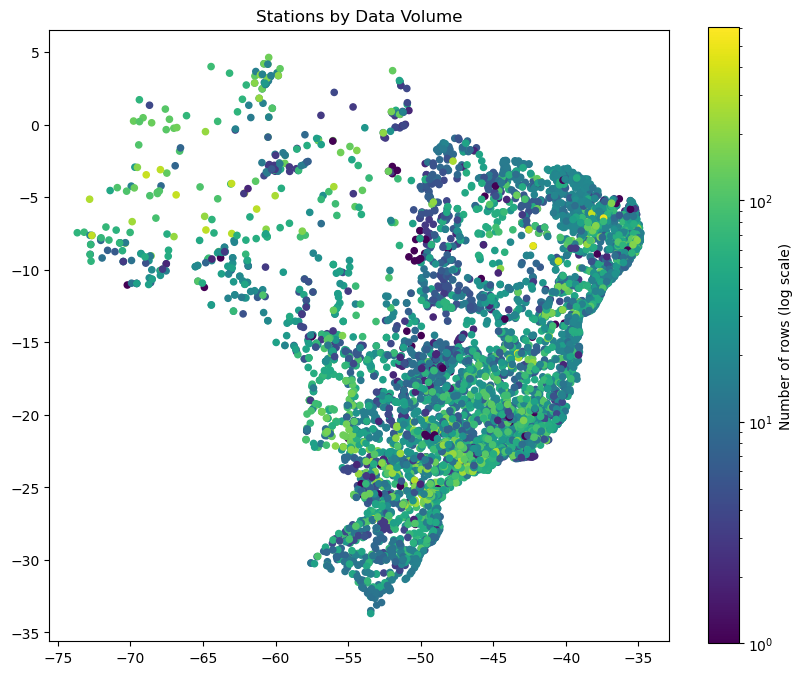

In [31]:
stations_quality = conn.sql(
    """
    SELECT station_code, longitude, latitude, COUNT(*) as data_rows
    FROM water_quality
        LEFT JOIN 
        stations
        USING (station_code)
    GROUP BY station_code, longitude, latitude;    
    """
    ).df()

stations_quality = gpd.GeoDataFrame(
    stations_quality[["station_code", "data_rows"]], 
    geometry = stations_quality.apply(lambda x: shapely.Point(x.longitude, x.latitude), axis=1)
    )

fig, ax = plt.subplots(figsize=(10, 8))

stations_quality.plot(
    column="data_rows",
    ax=ax,
    cmap="viridis",
    legend=True,                     # adds colorbar
    markersize=20,
    norm=colors.LogNorm(            # log scale
        vmin=stations_quality["data_rows"].min(),
        vmax=stations_quality["data_rows"].max()
    ),
    legend_kwds={"label": "Number of rows (log scale)"}
)

ax.set_title("Stations by Data Volume")
plt.show()

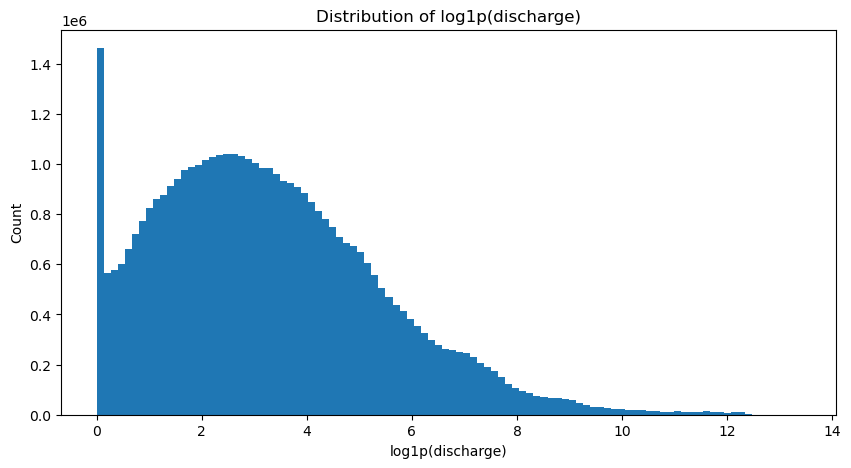

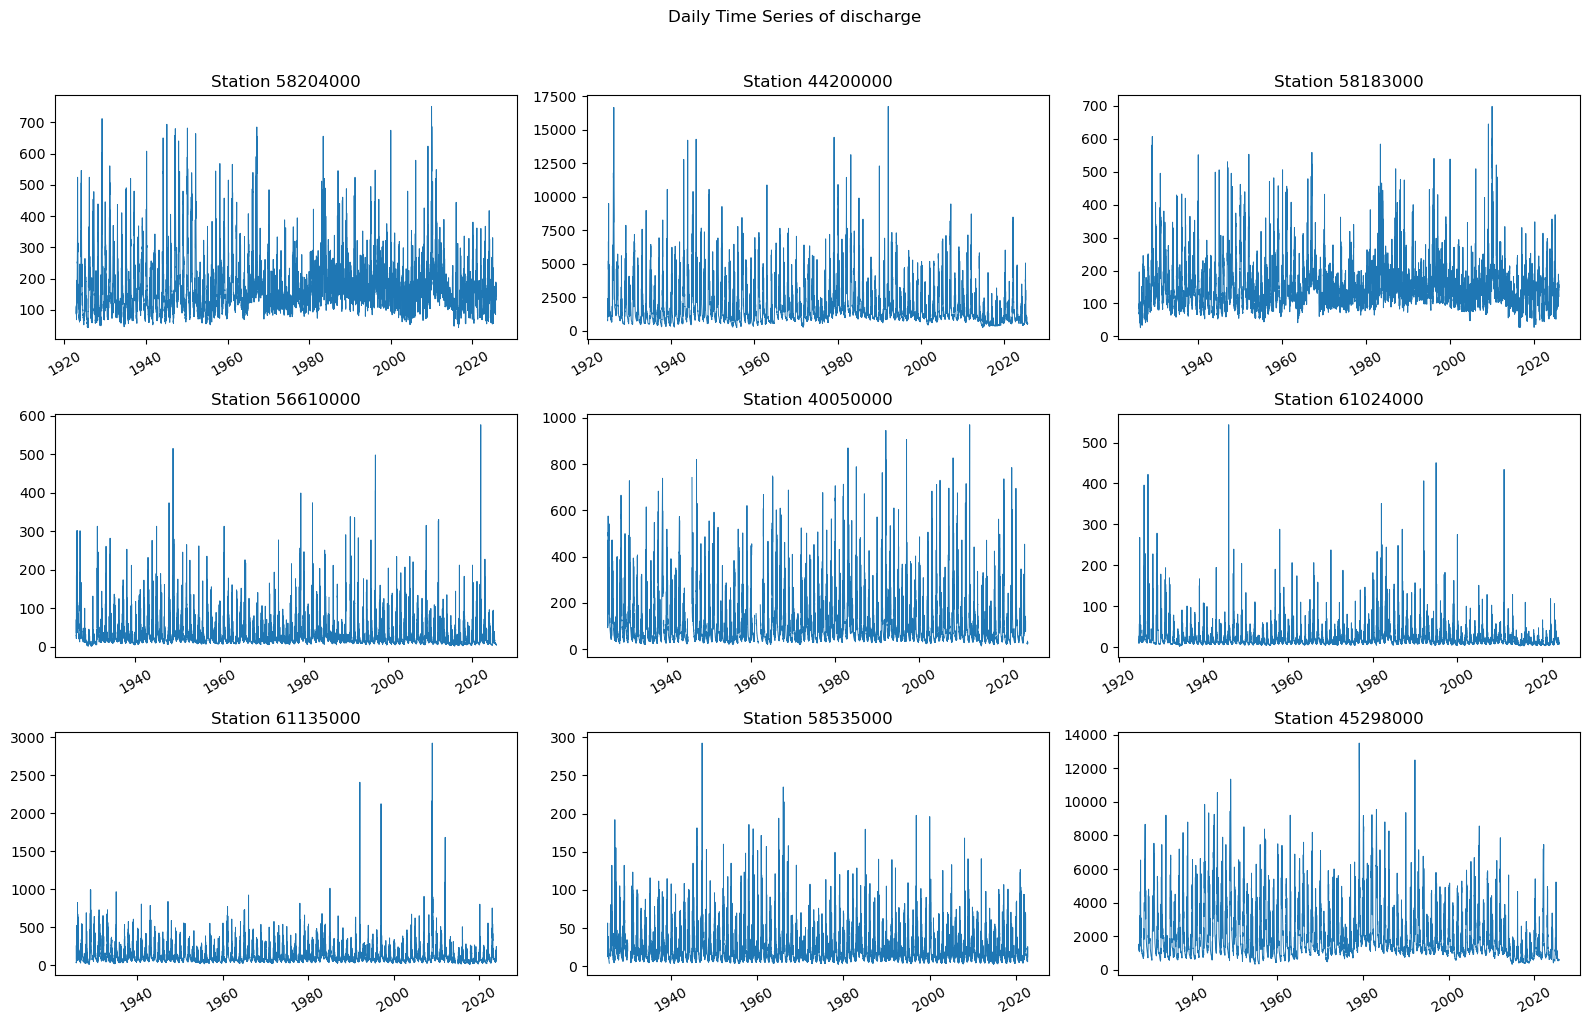

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import pandas as pd

data_dir = Path("/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/sensor_data")

streamflow_path = data_dir / "streamflow.parquet"

streamflow = pd.read_parquet(streamflow_path)

df = streamflow.copy()
df["date"] = pd.to_datetime(df["date"])

# assume you created discharge_clean already
col = "discharge_clean" if "discharge_clean" in df.columns else "discharge"

# -----------------------------
# Plot 1: Global distribution
# -----------------------------
plt.figure(figsize=(10, 5))
vals = df[col].dropna()
vals = vals[vals >= 0]
plt.hist(np.log1p(vals), bins=100)
plt.title(f"Distribution of log1p({col})")
plt.xlabel(f"log1p({col})")
plt.ylabel("Count")
plt.show()

# -----------------------------
# Plot 2: Small multiples time series
# -----------------------------
# choose stations: top 9 by number of observations
sample_stations = (
    df.groupby("station_code")[col]
      .size()
      .sort_values(ascending=False)
      .head(9)
      .index
)

fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=False, sharey=False)
axes = axes.flatten()

for ax, sid in zip(axes, sample_stations):
    s = df[df["station_code"] == sid].sort_values("date")
    ax.plot(s["date"], s[col], linewidth=0.7)
    ax.set_title(f"Station {sid}")
    ax.tick_params(axis="x", rotation=30)

for ax in axes[len(sample_stations):]:
    ax.axis("off")

fig.suptitle(f"Daily Time Series of {col}", y=1.02)
plt.tight_layout()
plt.show()

/scratch/ipykernel_1341759/1897961467.py:97: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


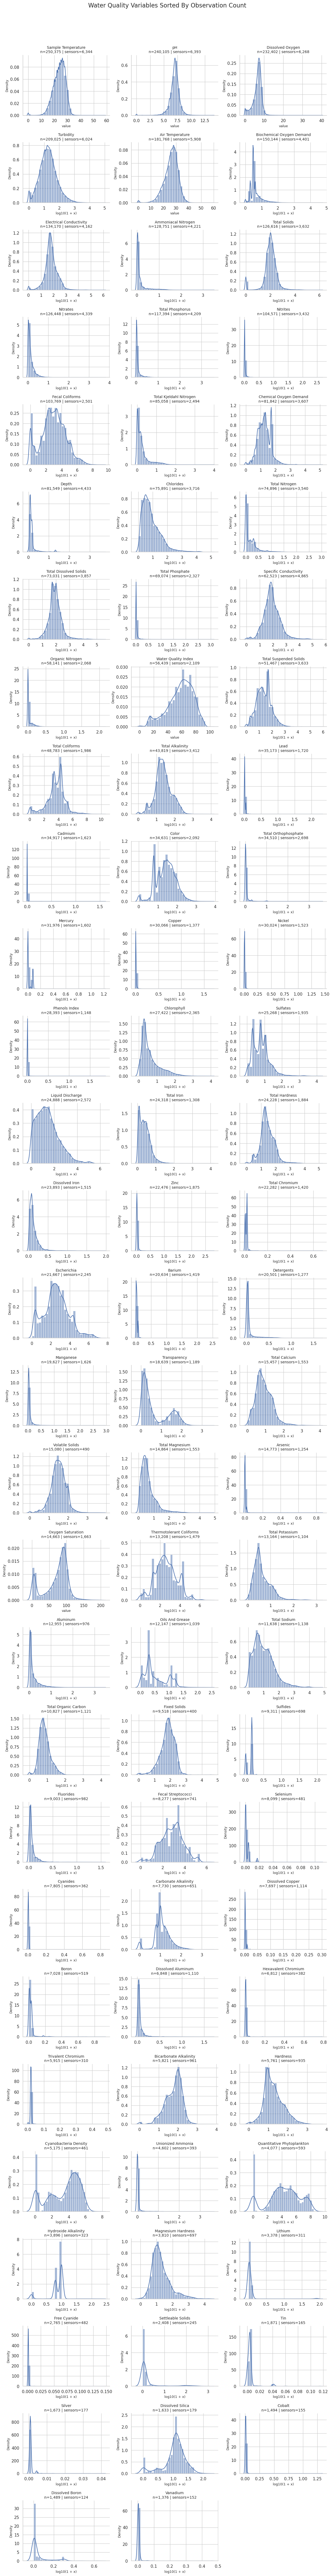

In [10]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Load preprocessed outputs
# -----------------------------
data_dir = Path("/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/sensor_data")

water_quality_path = data_dir / "water_quality.parquet"
transformations_path = data_dir / "water_quality_transformations.json"

water_quality = pd.read_parquet(water_quality_path)

with transformations_path.open("r", encoding="utf-8") as file:
    transformation_metadata = json.load(file)

recommendations = transformation_metadata["recommendations"]

# -----------------------------
# Keep variables with n > 1000
# -----------------------------
candidate_vars = [
    variable
    for variable, spec in recommendations.items()
    if variable in water_quality.columns
    and spec.get("statistics", {}).get("n", 0) > 1000
]

id_vars = ["station_code"] if "station_code" in water_quality.columns else []

plot_df = (
    water_quality[id_vars + candidate_vars]
    .melt(
        id_vars=id_vars,
        value_vars=candidate_vars,
        var_name="variable",
        value_name="value",
    )
    .dropna(subset=["value"])
)

plot_df["value"] = pd.to_numeric(plot_df["value"], errors="coerce")
plot_df = plot_df.dropna(subset=["value"])
plot_df = plot_df.loc[~plot_df["value"].isin([np.inf, -np.inf])].copy()

# -----------------------------
# Stats and ordering
# -----------------------------
stats = (
    plot_df.groupby("variable", observed=True)
    .agg(
        n_measurements=("value", "size"),
        n_sensors=("station_code", "nunique") if "station_code" in plot_df.columns else ("value", "size"),
    )
    .reset_index()
    .sort_values("n_measurements", ascending=False)
)

plot_vars = stats["variable"].tolist()
plot_df = plot_df.loc[plot_df["variable"].isin(plot_vars)].copy()
plot_df["variable"] = pd.Categorical(
    plot_df["variable"],
    categories=plot_vars,
    ordered=True,
)

stats_lookup = stats.set_index("variable").to_dict(orient="index")

# -----------------------------
# Automatic transforms from JSON
# -----------------------------
def apply_transform(values, transform_name):
    values = pd.to_numeric(values, errors="coerce")

    if transform_name == "log10_1p":
        return np.log10(values + 1)

    if transform_name == "log10":
        return np.where(values > 0, np.log10(values), np.nan)

    return values


plot_df["recommended_transform"] = plot_df["variable"].astype(str).map(
    lambda variable: recommendations[variable]["recommended_transform"]
)

plot_df["plot_value"] = plot_df.groupby(
    "variable",
    observed=True,
    group_keys=False,
).apply(
    lambda group: pd.Series(
        apply_transform(group["value"], group["recommended_transform"].iloc[0]),
        index=group.index,
    )
)

plot_df = plot_df.dropna(subset=["plot_value"])

# -----------------------------
# Plot
# -----------------------------
sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    plot_df,
    col="variable",
    col_order=plot_vars,
    col_wrap=3,
    sharex=False,
    sharey=False,
    height=3.4,
    aspect=1.25,
)

g.map_dataframe(
    sns.histplot,
    x="plot_value",
    bins=30,
    stat="density",
    element="bars",
    alpha=0.5,
)

g.map_dataframe(
    sns.kdeplot,
    x="plot_value",
    warn_singular=False,
)

for ax in g.axes.flat:
    if ax is None:
        continue

    raw_title = ax.get_title()
    variable = raw_title.split(" = ", 1)[1]
    row = stats_lookup[variable]
    transform_name = recommendations[variable]["recommended_transform"]
    expression = recommendations[variable]["expression"]

    title_name = variable.replace("_", " ").title()
    if variable == "ph":
        title_name = "pH"

    ax.set_title(
        f"{title_name}\n"
        f"n={row['n_measurements']:,} | sensors={row['n_sensors']:,}",
        fontsize=10,
    )
    ax.set_xlabel(expression if transform_name != "identity" else "value", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)

g.fig.subplots_adjust(top=0.96, hspace=0.45, wspace=0.25)
g.fig.suptitle(
    "Water Quality Variables Sorted By Observation Count",
    fontsize=16,
)

plt.show()


---

In [13]:
import numpy as np
import pandas as pd
import pyfixest as pf

import sys
sys.path.append("..")
from data.river_network import RiverNetwork

In [14]:
network = RiverNetwork()
network.load("../../data/river_network")
trenches = network.trenches.loc[:,["trench_id", "system_id"]].copy()
del network

In [20]:
sensor_data = pd.read_parquet("../../data/sensor_data/water_quality_assembled.parquet").reset_index()
sensor_data["year"] = sensor_data["date"].dt.year
sensor_data = sensor_data.query("year >= 1985 & year <= 2024").copy()
land_cover = pd.read_parquet("../../data/land_cover/land_cover_sensor_upstream.parquet")

In [23]:
analysis_data = pd.merge(
    sensor_data,
    land_cover,
    on=["trench_id", "year"]
)

analysis_data = analysis_data.merge(
    trenches,
    on="trench_id",
    how="left"
)

# quarter-year-system FE
analysis_data["quarter_year_system"] = (analysis_data.datetime.dt.year.astype(str) + "_" +
                                   analysis_data.datetime.dt.quarter.astype(str) + "_" +
                                   analysis_data.system_id.astype(str))

analysis_data["turbidity_log001"] = np.log10(analysis_data["turbidity"] + 0.01)
analysis_data["lc_0_10km_c41_shr_log001"] = np.log10(analysis_data["lc_0_10km_c41_shr"] + 0.001)
analysis_data["lc_10_50km_c41_shr_log001"] = np.log10(analysis_data["lc_10_50km_c41_shr"] + 0.001)

analysis_data

,station_code,datetime,rained,depth,air_temperature,sample_temperature,ph,color,turbidity,electrical_conductivity,...,lc_500km_plus_c40_shr,lc_500km_plus_c41_cnt,lc_500km_plus_c41_shr,lc_500km_plus_c42_cnt,lc_500km_plus_c42_shr,system_id,quarter_year_system,turbidity_log001,lc_0_10km_c41_shr_log001,lc_10_50km_c41_shr_log001
0,10100000,1996-07-01 10:00:00,0.0,NaN,NaN,27.600000,7.60,NaN,NaN,10.700000,...,NaN,0.0,NaN,0.0,NaN,0,1996_3_0,NaN,-3.0,-3.0
1,10100000,1996-09-11 16:00:00,0.0,NaN,NaN,25.200001,7.70,NaN,29.000000,203.000000,...,NaN,0.0,NaN,0.0,NaN,0,1996_3_0,1.462548,-3.0,-3.0
2,10100000,1996-12-21 10:55:00,0.0,NaN,NaN,NaN,7.80,NaN,20.000000,164.800003,...,NaN,0.0,NaN,0.0,NaN,0,1996_4_0,1.301247,-3.0,-3.0
3,10100000,1996-12-21 11:10:00,0.0,NaN,NaN,NaN,8.40,NaN,20.000000,161.600006,...,NaN,0.0,NaN,0.0,NaN,0,1996_4_0,1.301247,-3.0,-3.0
4,10100000,1996-12-21 11:25:00,0.0,NaN,NaN,NaN,8.30,NaN,17.000000,156.000000,...,NaN,0.0,NaN,0.0,NaN,0,1996_4_0,1.230704,-3.0,-3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243982,88850000,2023-09-06 12:00:00,0.0,0.5,16.0,11.300000,6.92,NaN,49.180000,NaN,...,NaN,0.0,NaN,0.0,NaN,26,2023_3_26,1.691877,-3.0,-3.0
243983,88850000,2023-11-17 15:00:00,0.0,0.5,28.0,19.900000,7.24,NaN,NaN,NaN,...,NaN,0.0,NaN,0.0,NaN,26,2023_4_26,NaN,-3.0,-3.0
243984,88850000,2024-02-29 10:30:00,0.0,0.5,26.0,23.299999,7.23,NaN,19.219999,NaN,...,NaN,0.0,NaN,0.0,NaN,26,2024_1_26,1.283979,-3.0,-3.0
243985,88850000,2024-07-25 10:45:00,0.0,0.5,19.0,14.900000,7.10,NaN,10.700000,NaN,...,NaN,0.0,NaN,0.0,NaN,26,2024_3_26,1.029789,-3.0,-3.0


In [24]:
pf.feols(
    "turbidity_log001 ~ lc_0_10km_c41_shr_log001 + lc_10_50km_c41_shr_log001 + I(streamflow_discharge_day / 100) + I(streamflow_discharge_mean_7d / 100) | station_code + quarter_year_system",
    vcov={"CRV1": "station_code"},
    data = analysis_data
).summary()

/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/river-pollution-brazil/.venv/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 1725 singleton fixed effect(s) dropped from the model.
  warnings.warn(


###

Estimation:  OLS
Dep. var.: turbidity_log001, Fixed effects: station_code + quarter_year_system
sample: None = all
Inference:  CRV1
Observations:  153052

| Coefficient                           |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------------------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| lc_0_10km_c41_shr_log001              |      0.057 |        0.072 |     0.780 |      0.435 | -0.086 |   0.199 |
| lc_10_50km_c41_shr_log001             |     -0.106 |        0.061 |    -1.725 |      0.085 | -0.226 |   0.014 |
| I(streamflow_discharge_day / 100)     |      0.001 |        0.000 |     1.745 |      0.081 | -0.000 |   0.002 |
| I(streamflow_discharge_mean_7d / 100) |     -0.001 |        0.000 |    -1.550 |      0.121 | -0.002 |   0.000 |
---
RMSE: 0.477 R2: 0.547 R2 Within: 0.0 


In [39]:
pf.feols(
    "turbidity_log001 ~ lc_0_10km_c1_cnt + lc_10_50km_c1_cnt + I(streamflow_discharge_day / 100) + I(streamflow_discharge_mean_7d / 100) | station_code + quarter_year_system",
    vcov = {"CRV1": "station_code"},
    data = analysis_data
).tidy()

/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/river-pollution-brazil/.venv/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 1822 singleton fixed effect(s) dropped from the model.
  warnings.warn(


,Estimate,Std. Error,t value,Pr(>|t|),2.5%,97.5%
Coefficient,,,,,,
lc_0_10km_c1_cnt,5.739319e-08,4.396359e-08,1.305471,0.191798,-2.879655e-08,1.435829e-07
lc_10_50km_c1_cnt,-3.428307e-08,3.235912e-08,-1.059456,0.289448,-9.772248e-08,2.915634e-08
I(streamflow_discharge_day / 100),8.936246e-04,4.889188e-04,1.827757,0.067651,-6.489085e-05,1.852140e-03
I(streamflow_discharge_mean_7d / 100),-7.967638e-04,4.799140e-04,-1.660222,0.096938,-1.737626e-03,1.440979e-04
